# recreate Fig. 8 from Eleanor and Calafat paper
## need rapid data and rapid sensitivty following johns et al.


In [1]:
import numpy as np
import xarray as xr
# plottng
import cmocean as cmo
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.transforms import Bbox
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker

import cartopy.crs as ccrs  # Projections list
import cartopy.feature as cfeature

import scipy
import scipy.stats as stats
from scipy.stats import pearsonr
from amocatlas import read

from process_data import MHT_selection

# data

In [16]:
ds_calafat = read.calafat2025()
ds_rapid_transport = read.rapid()
ds_rapid = xr.open_dataset("/Users/leadietz/Desktop/uni/masterthesis/coding/rapid/meridional_transports.nc")
mht_rapid = ds_rapid.heat_trans 

rapid_fc = ds_rapid_transport.TRANS_FC
rapid_ek = ds_rapid_transport.TRANS_EKMAN
rapid_mo = ds_rapid_transport.TRANS_UMO

Loading 1 Calafat et al. 2025 dataset(s):
  0. Bayesian_estimates_Atlantic_MHT.zip: No description available

Loading 1 RAPID 26°N dataset(s):
  0. moc_transports.nc: RAPID layer transport time series



In [24]:


## get the MHT from calafat data
MHT_dict = MHT_selection(ds_calafat, average=True, anomalies=True, one_band_sel=True, lat=26, statistics=True , ci=90, printout=False)    

lats = MHT_dict["lats"]
mht = MHT_dict["MHT"]
mht_anom = MHT_dict["MHT_anom"]
mht_26 = MHT_dict["MHT_lat"]
mht_26_anom = MHT_dict["MHT_lat_anom"]
mht_mean = MHT_dict["MHT_statistics"]["mean"]
mht_std = MHT_dict["MHT_statistics"]["std"] 
mht_ci = MHT_dict["MHT_statistics"]["ci"] 

# data
calafat_start = ds_calafat.isel(TIME=0).TIME.values
calafat_end = ds_calafat.isel(TIME=-1).TIME.values

# print(f"Calafat data starts at {calafat_start} and ends at {calafat_end}.")

length_timeseries = ( calafat_end - calafat_start ) / np.timedelta64(1, 'D') / 365.25  # convert to days first and then to years

# change to be 2004-2020 as calafat data
mht_rapid = mht_rapid.sel(time=slice(calafat_start, calafat_end))
mht_rapid_mean = mht_rapid.mean(dim="time", skipna=True)
mht_rapid_std = mht_rapid.std(dim="time", skipna=True)

rapid_ek = rapid_ek.sel(TIME=slice(calafat_start, calafat_end))

rapid_ek_mean = rapid_ek.mean(dim="TIME", skipna=True)


# rapid confidence intervals - following Johns et al. (2023a).
## total uncertatiny  = bias err + statistical err

1. bias err

In [23]:
# parameters needed
# sensitivties in PW/Sv
sens_fc = 0.07
sens_ek = 0.08
sens_mo = 0.05
# bias errors in PW
bias_fc = (1.7 / np.sqrt(8*length_timeseries)) * sens_fc
bias_ek = 0.15 * rapid_ek_mean * sens_ek
bias_mo = 1.0 * sens_mo
print(f"Bias error for FC: {bias_fc:.2f} PW")
print(f"Bias error for EK: {bias_ek:.2f} PW")
print(f"Bias error for MO: {bias_mo:.2f} PW")

total_bias_err = np.sqrt (bias_fc**2 + bias_ek**2 + bias_mo**2) # randomly combined
print(f"Total bias error: {total_bias_err:.2f} PW")

Bias error for FC: 0.01 PW
Bias error for EK: 0.04 PW
Bias error for MO: 0.05 PW
Total bias error: 0.07 PW


2. statistical err

In [ ]:
tau_I = 
std_mht = mht_rapid_std / np.sqrt(length_timeseries//(2*tau_I))  # standard error of the mean

# plotting

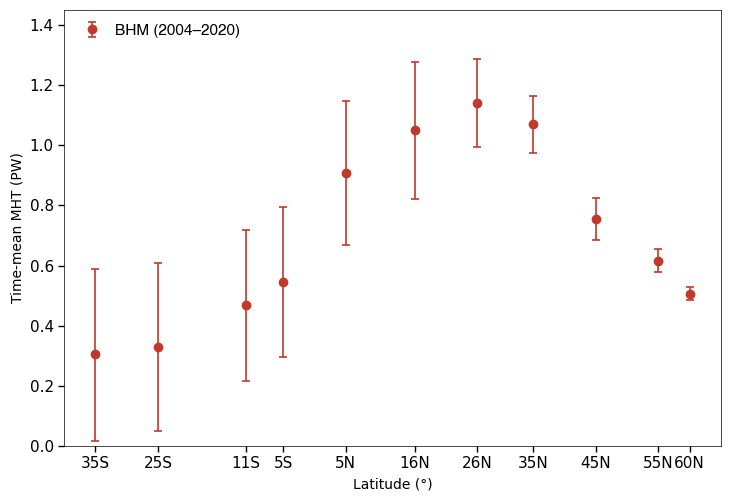

In [3]:

fig, ax = plt.subplots(figsize=(7.5, 5.2))

plt.rcParams.update({
    "font.family":  "Helvetica",   
    "font.size":    13,
    "axes.linewidth": 1.0,
})

ax.spines["left"].set_linewidth(0.5)
ax.spines["right"].set_linewidth(0.5)
ax.spines["top"].set_linewidth(0.5)
ax.spines["bottom"].set_linewidth(0.5)

ax.errorbar(
    lats, mht_mean,
    yerr=mht_ci,
    fmt="o",
    color="#C0392B",
    markerfacecolor="#C0392B",
    markersize=6,
    ecolor="#C0392B",
    elinewidth=1.2,
    capsize=3,
    capthick=1.2,
    zorder=5,
    label="BHM (2004–2020)",
)
    
# ax.scatter(
#     lats, mht_mean,
#     color="#C0392B",       # fill colour of the dots
#     edgecolors="#8B1A1A",  # outline colour
#     s=40,                  # marker size (points²)
#     zorder=5,
#     label="BHM (2004–2020)",
# )

ax.set_ylabel("Time-mean MHT (PW)")
ax.set_xlabel("Latitude (°)")
ax.set_ylim(0.0, 1.45)
ax.set_xlim(-40, 65)

xtick_pos    = [-35, -25, -11, -5,  5,  16, 26, 35, 45, 55, 60]
xtick_labels = ["35S","25S","11S","5S","5N","16N","26N","35N","45N","55N","60N"]
ax.set_xticks(xtick_pos)
ax.set_xticklabels(xtick_labels, fontsize=11)
ax.yaxis.set_major_locator(mticker.MultipleLocator(0.2))
ax.tick_params(axis="both", which="major", length=4, width=1.0, labelsize=11)

legend = ax.legend(
    loc="upper left",
    frameon=False,         
    fontsize=11,
    handlelength=1.8,
    handletextpad=0.6,
    labelspacing=0.4,
)

plt.tight_layout()
# plt.savefig("mht_plot.pdf", dpi=150, bbox_inches="tight")
plt.show()